# 01 - HK-LeadLag walkthrough

Hands-on tour of the framework. Each section uses a single class so the
same building blocks can be re-assembled in your own scripts.

1. **Wavelet primitives** - Daubechies + autocorrelation wavelets (cours Garcin slides 49-77)
2. **Hayashi-Yoshida** - non-synchronous cross-covariance
3. **WaveletLeadLagEstimator** - multi-scale lead-lag + heatmap 2D
4. **Simulation** - Brownian + Heston modulation + Lo-MacKinlay sampling
5. **Monte Carlo** - replicate Tables 2-3 of HK20 + box-plots per scale
6. **Crypto scalogram** - visualise multi-scale structure on real data
7. **Estimator comparison** - HK vs HRY baseline


In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

## 1. Wavelet primitives

Mapping cours Garcin :
* slide 49-55 : construction Daubechies, fonction d'échelle, moments nuls
* slide 54 : QMR relationship g_p = (-1)^(p+1) h_{L-p-1}
* slide 56 : Daubechies mother wavelet (5 moments nuls)
* slide 70 : analyse multirésolution

### 1.a - Vue d'ensemble des filtres Daubechies (pédagogique)

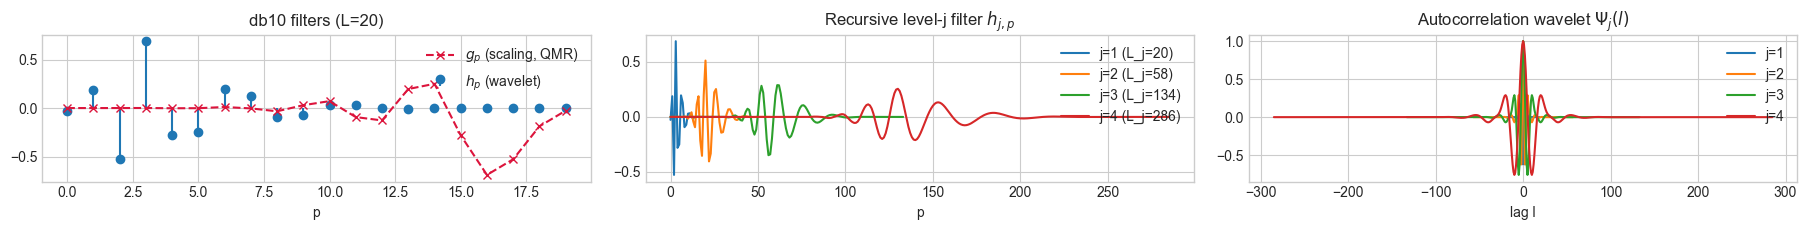

In [2]:
from hk_leadlag.viz.plots import LeadLagPlotter

LeadLagPlotter(figsize=(13, 4)).plot_daubechies_filter(
    wavelet_name='db10', levels=[1, 2, 3, 4],
);

**Lecture** :
* Panel 1 : le filtre Daubechies `h_p` (bleu, wavelet) et son miroir QMR `g_p` (rouge, scaling). Cas db10, L=20.
* Panel 2 : le filtre récursif `h_{j,p}` pour j=1..4. La longueur double à chaque niveau : L_j = (2^j − 1)(L−1) + 1.
* Panel 3 : l'autocorrelation wavelet `Ψ_j(l)` - c'est le filtre passe-bande utilisé par HK pour isoler la bande de fréquence à l'échelle j.

### 1.b - Transfer functions H_{j,L}(ω)

On vérifie que chaque `H_{j,L}` se rapproche bien d'une **indicatrice de bande** (idéal Littlewood-Paley).

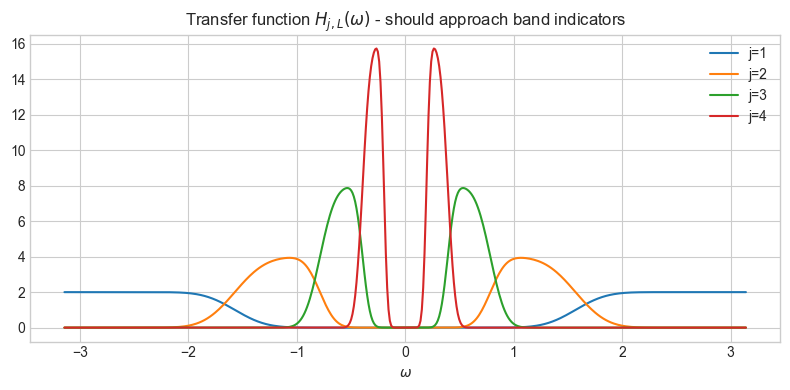

In [3]:
from hk_leadlag.wavelet import DaubechiesFilter, transfer_function

daub = DaubechiesFilter('db10')
fig, ax = plt.subplots(figsize=(8, 4))
for j in [1, 2, 3, 4]:
    omega, H = transfer_function(daub, j, n_freq=512)
    ax.plot(omega, H, label=f'j={j}')
ax.set_title(r'Transfer function $H_{j,L}(\omega)$ - should approach band indicators')
ax.set_xlabel(r'$\omega$'); ax.legend()
fig.tight_layout();

## 2. Hayashi-Yoshida cross-covariance

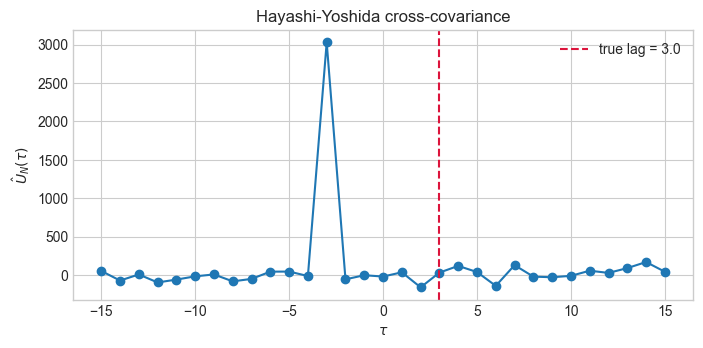

In [4]:
from hk_leadlag.base import NonSyncSeries
from hk_leadlag.estimators.hayashi_yoshida import HayashiYoshidaEstimator

# Synthetic correlated series with a known lag.
n = 5_000
z1 = rng.standard_normal(n)
z2 = 0.6 * z1 + np.sqrt(1 - 0.6**2) * rng.standard_normal(n)
t = np.arange(n + 1, dtype=float)
X1 = np.concatenate([[0], np.cumsum(z1)])
X2 = np.concatenate([[0], np.cumsum(z2)])
true_lag = 3.0
series = NonSyncSeries(t, X1, t + true_lag, X2)

grid = np.arange(-15, 16, dtype=float)
hy = HayashiYoshidaEstimator(grid=grid)
u_hat = hy.cross_cov(series)

plt.figure(figsize=(8, 3.5))
plt.plot(grid, u_hat, marker='o')
plt.axvline(true_lag, color='crimson', ls='--', label=f'true lag = {true_lag}')
plt.xlabel(r'$\tau$'); plt.ylabel(r'$\hat U_N(\tau)$')
plt.title('Hayashi-Yoshida cross-covariance'); plt.legend();

## 3. Multi-scale lead-lag estimator

In [5]:
from hk_leadlag.estimators import WaveletLeadLagEstimator
from hk_leadlag.simulation import BivariateBrownianSimulator, RegularSampler, LoMacKinlaySampler

true_R = [0.5, 0.5, 0.7, 0.5]
true_theta = [1, 1, 2, 2]
sim = BivariateBrownianSimulator(R=true_R, theta=true_theta, daub=DaubechiesFilter('db4'))
rng = np.random.default_rng(0)
times, X1, X2 = sim.simulate(8192, dt=1.0, rng=rng)
series = RegularSampler().sample(times, X1, X2, rng)

est = WaveletLeadLagEstimator(
    delta_N=1.0, j_max=len(true_theta), grid_half_width=20,
    daub=DaubechiesFilter('db4'),
)
result = est.fit(series)
for j, t_hat, t_true in zip(result.levels, result.theta_hat, true_theta):
    print(f'j={int(j)}  theta_hat={t_hat:+.2f}  (true={t_true})')

j=1  theta_hat=+1.00  (true=1)
j=2  theta_hat=+1.00  (true=1)
j=3  theta_hat=+1.00  (true=2)
j=4  theta_hat=+1.00  (true=2)


### 3.a - Multi-panel contrast (un panneau par échelle)

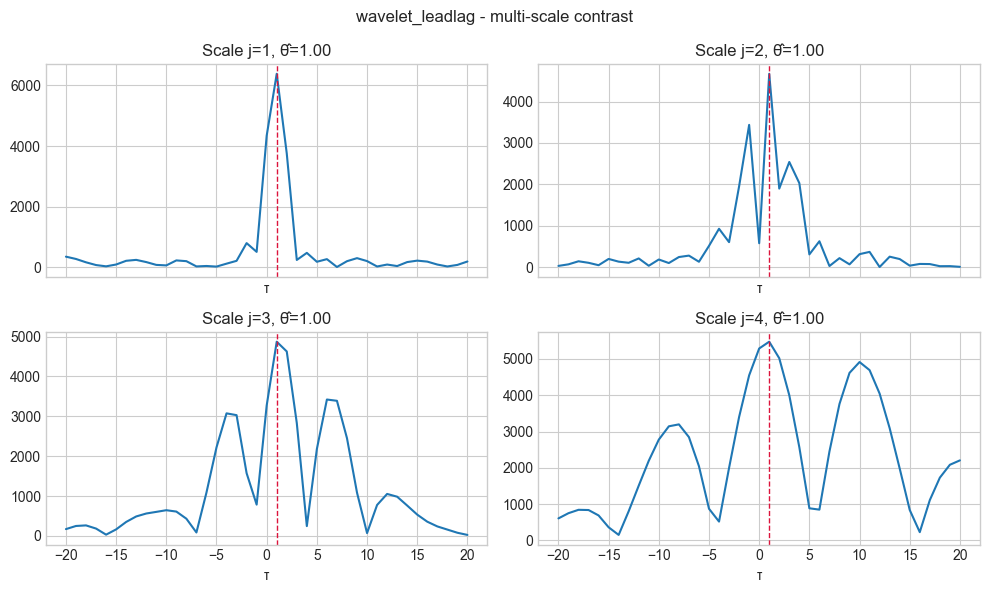

In [6]:
LeadLagPlotter().plot_contrast(result);

### 3.b - Heatmap 2D

**Visualisation la plus parlante du papier** : on superpose toutes les échelles dans une seule heatmap (scale × lag), avec la trajectoire `θ̂_j` en pointillés blancs. Idéal pour les slides de soutenance.

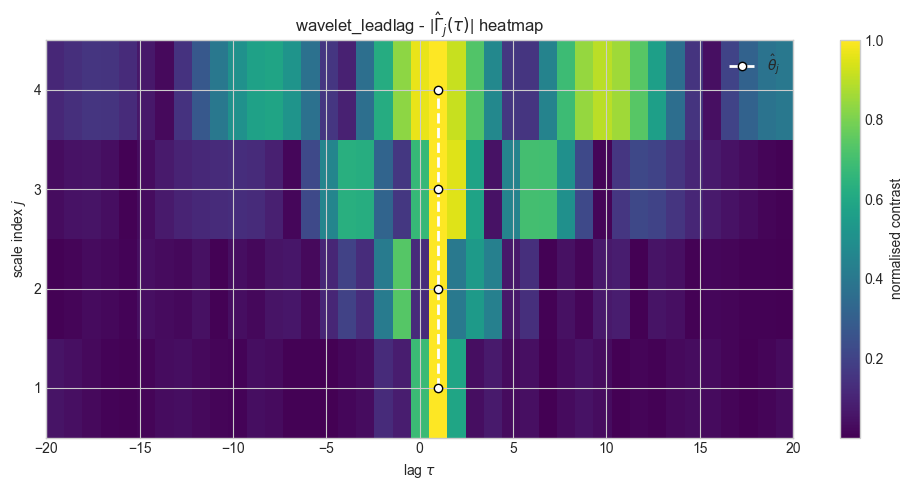

In [7]:
LeadLagPlotter(figsize=(10, 5)).plot_heatmap_2d(result, normalise=True);

**Lecture** : chaque ligne horizontale est une échelle j. Le pic de couleur (jaune) à chaque ligne donne le `θ̂_j`. La courbe pointillée blanche relie les argmax - elle visualise **comment le lead-lag change selon l'horizon**, exactement le message de HK et du cours Garcin slide 77.

## 4. Heston-modulated Brownian + Lo-MacKinlay sampling

theta_hat under Heston + non-sync: [1. 1. 1. 0.]


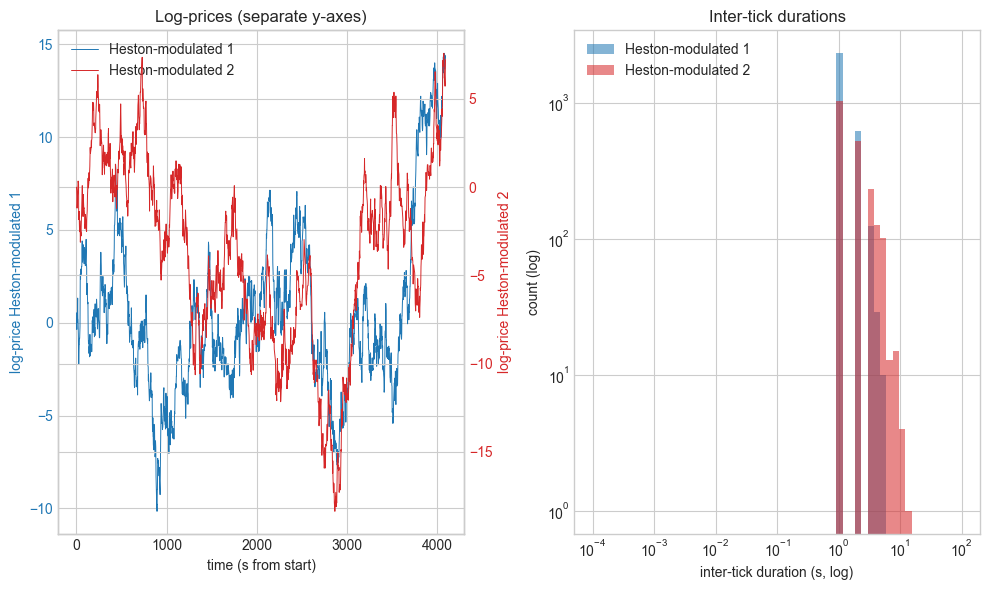

In [8]:
from hk_leadlag.simulation import HestonModulatedSimulator, HestonVolatilitySimulator

het_sim = HestonModulatedSimulator(
    brownian=BivariateBrownianSimulator(R=true_R, theta=true_theta, daub=DaubechiesFilter('db4')),
    heston1=HestonVolatilitySimulator(),
    heston2=HestonVolatilitySimulator(),
)
rng = np.random.default_rng(1)
times, X1, X2 = het_sim.simulate(4096, dt=1.0, rng=rng)
series_h = LoMacKinlaySampler(p1=0.25, p2=0.5).sample(times, X1, X2, rng)
result_h = est.fit(series_h)
print('theta_hat under Heston + non-sync:', result_h.theta_hat)

LeadLagPlotter().plot_data_overview(
    series_h.times1, series_h.prices1, series_h.times2, series_h.prices2,
    labels=('Heston-modulated 1', 'Heston-modulated 2'),
);

## 5. Mini Monte Carlo + box-plot per scale

In [9]:
from hk_leadlag.analysis.monte_carlo import MonteCarloRunner

runner = MonteCarloRunner(
    simulator=BivariateBrownianSimulator(R=true_R, theta=true_theta, daub=DaubechiesFilter('db4')),
    sampler=LoMacKinlaySampler(p1=0.25, p2=0.75),
    estimator=est,
    n_paths=50, n_steps=4096, dt=1.0, seed=0,
)
mc = runner.run(true_theta=true_theta)
print(mc.summary())

   level_j  true  median  MAD  bias
0        1   1.0     1.0  0.0   0.0
1        2   1.0     1.0  0.0   0.0
2        3   2.0     1.0  0.0  -1.0
3        4   2.0     0.0  1.0  -2.0


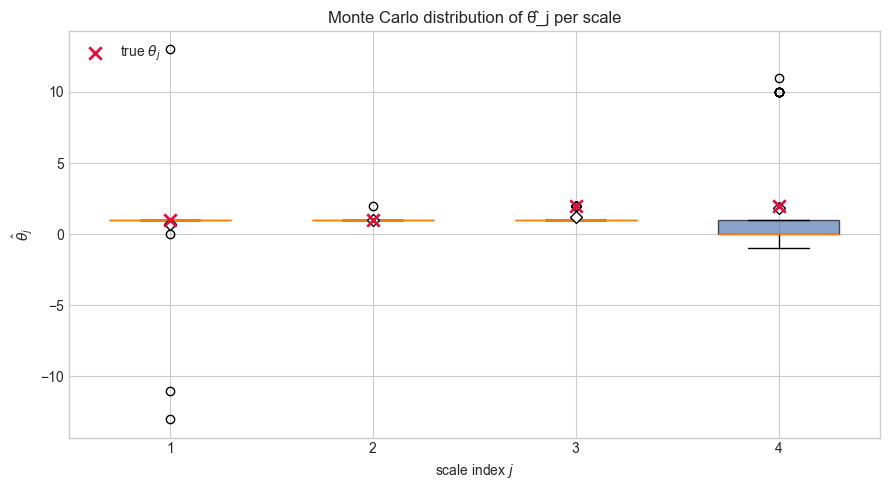

In [10]:
LeadLagPlotter(figsize=(9, 5)).plot_mc_boxplot(
    panel=mc.estimates,
    levels=mc.levels,
    true_theta=mc.true_theta,
);

**Lecture** : chaque box-plot est la distribution de `θ̂_j` sur les 50 paths MC. Les croix rouges marquent la vraie valeur `θ_j`. Si la médiane (ligne dans la box) tombe sur la croix rouge, l'estimateur est **non-biaisé**. Cette figure correspond à la **Figure 1 de HK20**.

## 6. Scalogramme sur série crypto

Mapping cours Garcin :
* slide 51 : exemple de projection sur base wavelet
* slide 63-65 : scalogramme NOKUSD
* slide 99-100 : ondelette de Morlet (utilisée ici)

On simule une série de prix BTCUSDT-like pour la démo. Pour brancher une vraie série Binance, utilise `BinanceTradesLoader` (cf. module `hk_leadlag.data.binance`).

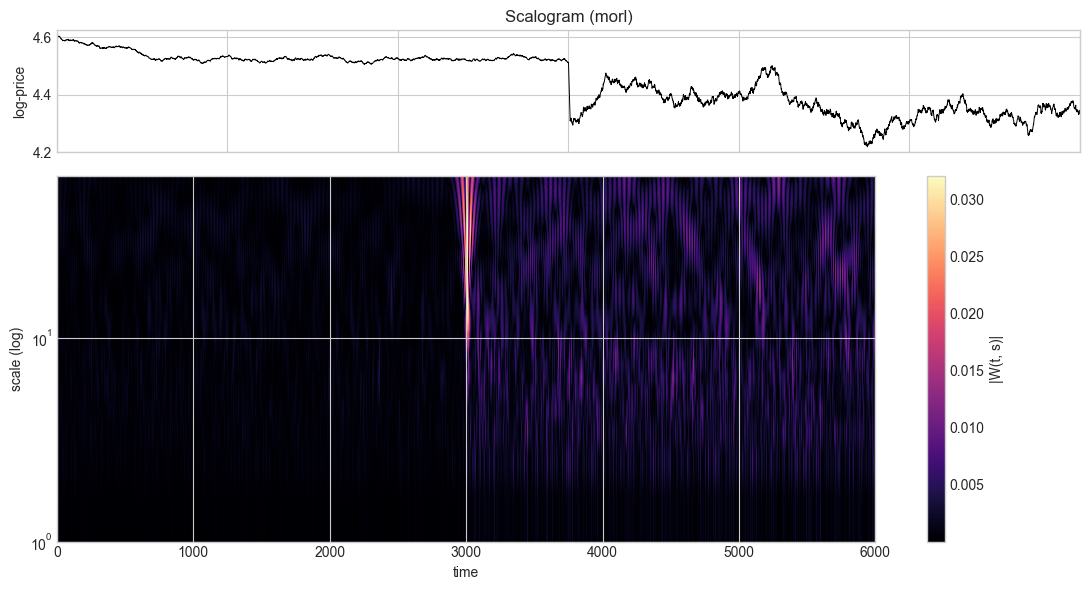

In [11]:
# Demo: synthetic GBM with a sharp regime change at t=3000 (mimics a flash crash).
rng = np.random.default_rng(7)
n = 6000
vol = np.where(np.arange(n) < 3000, 0.001, 0.004)  # vol triples at t=3000
returns = vol * rng.standard_normal(n)
returns[3000:3010] -= 0.02  # add a drawdown spike
times_demo = np.arange(n, dtype=float)
prices_demo = np.concatenate([[100.0], 100.0 * np.exp(np.cumsum(returns))])
log_prices = np.log(prices_demo)

LeadLagPlotter(figsize=(11, 6)).plot_scalogram(
    times=np.arange(len(log_prices), dtype=float),
    prices=log_prices,
    scales=np.arange(1, 64),
    wavelet='morl',
);

**Lecture** : la heatmap montre l'énergie wavelet `|W(t, s)|` pour chaque (temps, échelle). L'énergie remonte sur toutes les échelles après le choc à t≈3000 - c'est la **signature multi-échelle d'une singularité** (cf. slides 86-94 du cours sur les modules maxima).

Pour une vraie analyse crypto, remplace les lignes ci-dessus par :
```python
from hk_leadlag.data import BinanceTradesLoader
from datetime import date
loader = BinanceTradesLoader('BTCUSDT', 'ETHUSDT', date(2026, 4, 1), date(2026, 4, 7))
series_crypto = loader.load()
LeadLagPlotter().plot_scalogram(series_crypto.times1, series_crypto.prices1, scales=np.arange(1, 256))
```

## 7. Comparaison HK vs HRY (baseline)

Pour défendre le papier, il faut montrer que HK fait **mieux** que le baseline HRY (single-scale). Voici comment comparer en une figure.

In [12]:
from hk_leadlag.estimators import HRYEstimator

# Re-simulate a synchronous path for comparison.
rng = np.random.default_rng(42)
sim = BivariateBrownianSimulator(R=true_R, theta=true_theta, daub=DaubechiesFilter('db4'))
times, X1, X2 = sim.simulate(8192, dt=1.0, rng=rng)
series_cmp = LoMacKinlaySampler(p1=0.25, p2=0.5).sample(times, X1, X2, rng)

res_hk = WaveletLeadLagEstimator(
    delta_N=1.0, j_max=4, grid_half_width=20, daub=DaubechiesFilter('db4'),
).fit(series_cmp)
res_hry = HRYEstimator(delta_N=1.0, grid_half_width=20).fit(series_cmp)

print('HK multi-scale theta_hat:', res_hk.theta_hat)
print('HRY single-scale theta_hat:', res_hry.theta_hat)

HK multi-scale theta_hat: [1. 1. 1. 0.]
HRY single-scale theta_hat: [1.]


**Interprétation** : HRY est **single-scale** : il donne **un seul** lead-lag agrégé. HK donne **un par échelle** → il capte la structure multi-fréquentielle que HRY moyenne en un seul nombre. C'est exactement le constat fait dans le cours Garcin slide 76-77 (Mikko Ranta) : DAX leader sur 1 mois, SP500 sur 1 jour - un single-scale rate complètement cette information.